In [0]:
%pip install scikit-learn pandas matplotlib seaborn jinja2

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [0]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from jinja2 import Template
from datetime import datetime

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, precision_score, recall_score, f1_score
)
from sklearn.preprocessing import LabelEncoder

np.random.seed(42)
plt.style.use('seaborn-v0_8-whitegrid')
print("All libraries loaded")

All libraries loaded


In [0]:
n = 2000

data = pd.DataFrame({
    'age':                 np.random.randint(18, 75, n),
    'gender':              np.random.choice(['Male', 'Female'], n, p=[0.52, 0.48]),
    'region':              np.random.choice(['North', 'South', 'East', 'West'], n),
    'tenure_months':       np.random.randint(1, 72, n),
    'monthly_charges':     np.round(np.random.uniform(20, 130, n), 2),
    'num_products':        np.random.randint(1, 6, n),
    'has_support_contract':np.random.choice([0, 1], n, p=[0.4, 0.6]),
    'num_complaints':      np.random.randint(0, 8, n),
    'paperless_billing':   np.random.choice([0, 1], n),
})

# Churn probability — with subtle age and gender bias introduced
churn_prob = (
    0.28
    + 0.06  * data['num_complaints']
    - 0.004 * data['tenure_months']
    + 0.002 * data['monthly_charges']
    - 0.06  * data['has_support_contract']
    - 0.003 * (data['age'] - 40)           # older customers churn less
    + 0.04  * (data['gender'] == 'Female')  # subtle gender bias
    - 0.03  * data['num_products']
)
data['churn'] = (np.random.random(n) < churn_prob.clip(0.05, 0.95)).astype(int)

print(f"Dataset: {data.shape[0]} rows, {data.shape[1]} columns")
print(f"Overall churn rate: {data['churn'].mean():.1%}")
print("\nChurn rate by gender:")
print(data.groupby('gender')['churn'].mean().round(3).to_string())
print("\nFirst 5 rows:")
data.head()

Dataset: 2000 rows, 10 columns
Overall churn rate: 36.0%

Churn rate by gender:
gender
Female    0.374
Male      0.348

First 5 rows:


,age,gender,region,tenure_months,monthly_charges,num_products,has_support_contract,num_complaints,paperless_billing,churn
0,56,Male,South,14,28.65,4,0,3,0,0
1,69,Female,West,61,56.40,5,1,7,1,1
2,46,Female,East,71,47.31,5,0,7,1,0
3,32,Male,South,46,128.68,4,0,6,0,0
4,60,Female,South,32,62.83,1,0,1,0,1


In [0]:
df = data.copy()
le_gender = LabelEncoder()
le_region = LabelEncoder()
df['gender_enc'] = le_gender.fit_transform(df['gender'])
df['region_enc'] = le_region.fit_transform(df['region'])

FEATURES = ['age', 'gender_enc', 'tenure_months', 'monthly_charges',
            'num_products', 'has_support_contract', 'num_complaints',
            'paperless_billing', 'region_enc']

FEATURE_LABELS = ['Age', 'Gender', 'Tenure (months)', 'Monthly charges',
                  'Num products', 'Support contract', 'Num complaints',
                  'Paperless billing', 'Region']

X = df[FEATURES]
y = df['churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

rf  = RandomForestClassifier(n_estimators=100, random_state=42)
lr  = LogisticRegression(max_iter=1000, random_state=42)

rf.fit(X_train, y_train)
lr.fit(X_train, y_train)

rf_pred  = rf.predict(X_test)
rf_prob  = rf.predict_proba(X_test)[:, 1]
lr_pred  = lr.predict(X_test)
lr_prob  = lr.predict_proba(X_test)[:, 1]

metrics = {
    'Random Forest': {
        'auc':       round(roc_auc_score(y_test, rf_prob), 3),
        'precision': round(precision_score(y_test, rf_pred), 3),
        'recall':    round(recall_score(y_test, rf_pred), 3),
        'f1':        round(f1_score(y_test, rf_pred), 3),
        'accuracy':  round((rf_pred == y_test).mean(), 3),
    },
    'Logistic Regression': {
        'auc':       round(roc_auc_score(y_test, lr_prob), 3),
        'precision': round(precision_score(y_test, lr_pred), 3),
        'recall':    round(recall_score(y_test, lr_pred), 3),
        'f1':        round(f1_score(y_test, lr_pred), 3),
        'accuracy':  round((lr_pred == y_test).mean(), 3),
    }
}

print("Models trained")
for name, m in metrics.items():
    print(f"\n{name}")
    for k, v in m.items():
        print(f"  {k}: {v}")

Models trained

Random Forest
  auc: 0.7
  precision: 0.651
  recall: 0.375
  f1: 0.476
  accuracy: 0.702

Logistic Regression
  auc: 0.743
  precision: 0.6
  recall: 0.354
  f1: 0.445
  accuracy: 0.682


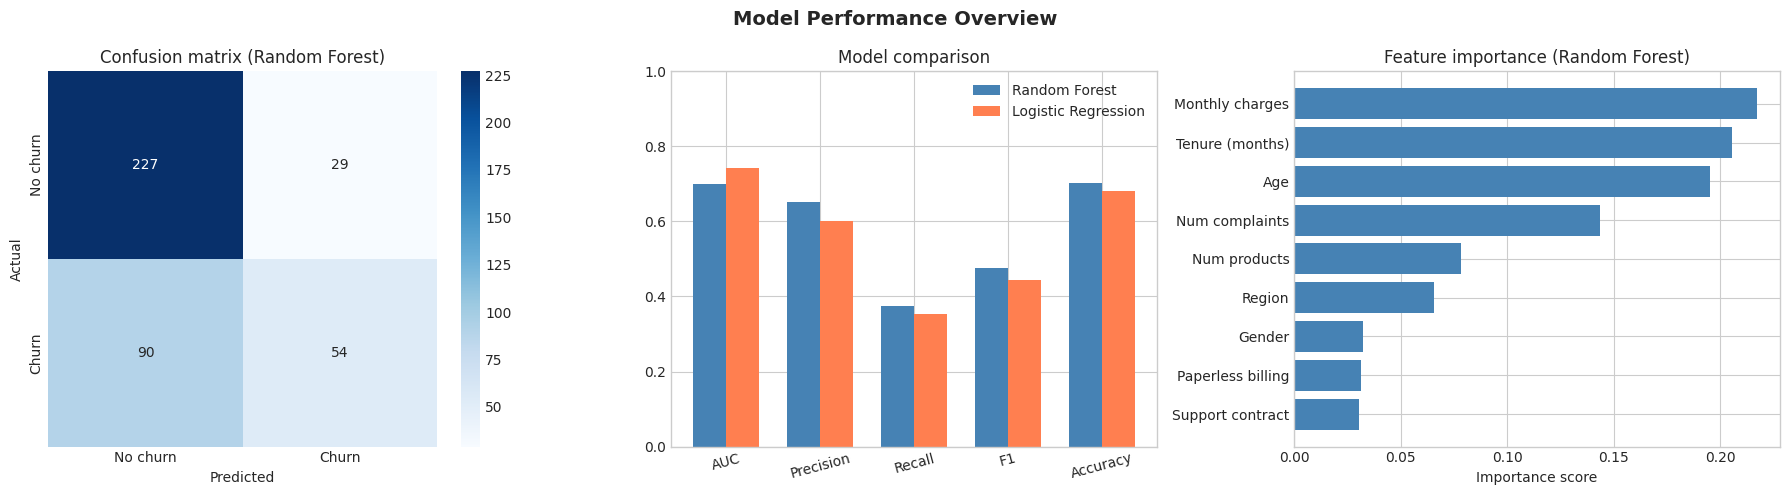

Saved model_performance.png


In [0]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Model Performance Overview', fontsize=14, fontweight='bold')

cm = confusion_matrix(y_test, rf_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['No churn', 'Churn'],
            yticklabels=['No churn', 'Churn'])
axes[0].set_title('Confusion matrix (Random Forest)')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# Model comparison bar chart
metric_names = ['AUC', 'Precision', 'Recall', 'F1', 'Accuracy']
rf_vals  = [metrics['Random Forest'][k]  for k in ['auc','precision','recall','f1','accuracy']]
lr_vals  = [metrics['Logistic Regression'][k] for k in ['auc','precision','recall','f1','accuracy']]
x = np.arange(len(metric_names))
w = 0.35
axes[1].bar(x - w/2, rf_vals, w, label='Random Forest', color='steelblue')
axes[1].bar(x + w/2, lr_vals, w, label='Logistic Regression', color='coral')
axes[1].set_xticks(x)
axes[1].set_xticklabels(metric_names, rotation=15)
axes[1].set_ylim(0, 1)
axes[1].set_title('Model comparison')
axes[1].legend()

# Feature importance
importances = rf.feature_importances_
sorted_idx  = np.argsort(importances)
axes[2].barh([FEATURE_LABELS[i] for i in sorted_idx],
             importances[sorted_idx], color='steelblue')
axes[2].set_title('Feature importance (Random Forest)')
axes[2].set_xlabel('Importance score')

plt.tight_layout()
plt.savefig('model_performance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved model_performance.png")

In [0]:
test_df = X_test.copy()
test_df['actual']    = y_test.values
test_df['rf_pred']   = rf_pred
test_df['rf_prob']   = rf_prob
test_df['gender']    = data.loc[X_test.index, 'gender'].values
test_df['region']    = data.loc[X_test.index, 'region'].values
test_df['age_group'] = pd.cut(
    data.loc[X_test.index, 'age'],
    bins=[17, 30, 45, 60, 75],
    labels=['18-30', '31-45', '46-60', '61-75']
)

def fairness_metrics(df, group_col):
    rows = []
    for group, grp in df.groupby(group_col, observed=True):
        rows.append({
            'Group': str(group),
            'N': len(grp),
            'Actual churn rate':    round(grp['actual'].mean(), 3),
            'Predicted churn rate': round(grp['rf_pred'].mean(), 3),
            'Recall (equal opp.)':  round(recall_score(grp['actual'], grp['rf_pred'], zero_division=0), 3),
            'Precision (pred. par.)': round(precision_score(grp['actual'], grp['rf_pred'], zero_division=0), 3),
            'Avg churn prob':       round(grp['rf_prob'].mean(), 3),
        })
    return pd.DataFrame(rows).set_index('Group')

gender_fairness = fairness_metrics(test_df, 'gender')
age_fairness    = fairness_metrics(test_df, 'age_group')
region_fairness = fairness_metrics(test_df, 'region')

print("=== Gender fairness ===")
print(gender_fairness.to_string())
print("\n=== Age group fairness ===")
print(age_fairness.to_string())
print("\n=== Region fairness ===")
print(region_fairness.to_string())

=== Gender fairness ===
          N  Actual churn rate  Predicted churn rate  Recall (equal opp.)  Precision (pred. par.)  Avg churn prob
Group                                                                                                            
Female  190              0.400                 0.221                0.421                   0.762           0.363
Male    210              0.324                 0.195                0.324                   0.537           0.343

=== Age group fairness ===
         N  Actual churn rate  Predicted churn rate  Recall (equal opp.)  Precision (pred. par.)  Avg churn prob
Group                                                                                                           
18-30   84              0.476                 0.381                0.575                   0.719           0.433
31-45  107              0.327                 0.196                0.314                   0.524           0.353
46-60  102              0.373           

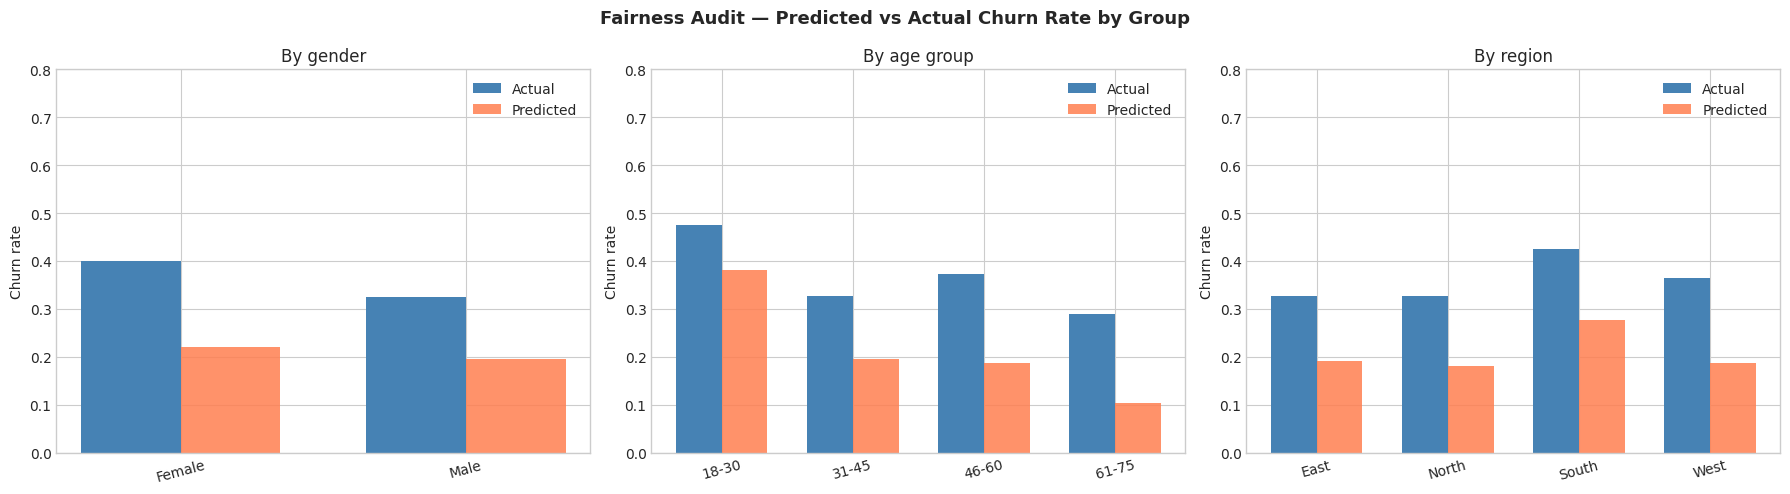

Saved fairness_audit.png


In [0]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Fairness Audit — Predicted vs Actual Churn Rate by Group', fontsize=13, fontweight='bold')

for ax, (title, df_fair) in zip(axes, [
    ('By gender',   gender_fairness),
    ('By age group', age_fairness),
    ('By region',   region_fairness)
]):
    groups = df_fair.index.tolist()
    x = np.arange(len(groups))
    w = 0.35
    ax.bar(x - w/2, df_fair['Actual churn rate'],    w, label='Actual',    color='steelblue')
    ax.bar(x + w/2, df_fair['Predicted churn rate'], w, label='Predicted', color='coral', alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels(groups, rotation=15)
    ax.set_title(title)
    ax.set_ylabel('Churn rate')
    ax.set_ylim(0, 0.8)
    ax.legend()

plt.tight_layout()
plt.savefig('fairness_audit.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved fairness_audit.png")

In [0]:
def demographic_parity_gap(df_fair):
    """Max difference in predicted churn rate across groups."""
    rates = df_fair['Predicted churn rate']
    return round(rates.max() - rates.min(), 3)

def equal_opportunity_gap(df_fair):
    """Max difference in recall across groups."""
    recalls = df_fair['Recall (equal opp.)']
    return round(recalls.max() - recalls.min(), 3)

bias_scores = {
    'Gender': {
        'demographic_parity_gap':  demographic_parity_gap(gender_fairness),
        'equal_opportunity_gap':   equal_opportunity_gap(gender_fairness),
    },
    'Age group': {
        'demographic_parity_gap':  demographic_parity_gap(age_fairness),
        'equal_opportunity_gap':   equal_opportunity_gap(age_fairness),
    },
    'Region': {
        'demographic_parity_gap':  demographic_parity_gap(region_fairness),
        'equal_opportunity_gap':   equal_opportunity_gap(region_fairness),
    },
}

# Risk rating logic
max_dp_gap  = max(v['demographic_parity_gap'] for v in bias_scores.values())
max_eo_gap  = max(v['equal_opportunity_gap']  for v in bias_scores.values())
auc_score   = metrics['Random Forest']['auc']

if max_dp_gap > 0.10 or max_eo_gap > 0.15 or auc_score < 0.70:
    risk_rating = 'HIGH'
    risk_color  = '#E24B4A'
    risk_reason = 'Significant fairness gaps detected across protected groups.'
elif max_dp_gap > 0.05 or max_eo_gap > 0.08 or auc_score < 0.80:
    risk_rating = 'MEDIUM'
    risk_color  = '#EF9F27'
    risk_reason = 'Moderate fairness concerns — mitigation recommended before deployment.'
else:
    risk_rating = 'LOW'
    risk_color  = '#1D9E75'
    risk_reason = 'Model meets baseline fairness thresholds.'

print(f"Max demographic parity gap: {max_dp_gap}")
print(f"Max equal opportunity gap:  {max_eo_gap}")
print(f"\n>>> RISK RATING: {risk_rating} — {risk_reason}")

Max demographic parity gap: 0.278
Max equal opportunity gap:  0.349

>>> RISK RATING: HIGH — Significant fairness gaps detected across protected groups.


In [0]:
html_template = """
<!DOCTYPE html>
<html lang="en">
<head>
  <meta charset="UTF-8">
  <title>AI Governance Report</title>
  <style>
    body { font-family: Arial, sans-serif; max-width: 900px; margin: 40px auto; color: #222; line-height: 1.6; }
    h1 { border-bottom: 3px solid #185FA5; padding-bottom: 10px; }
    h2 { color: #185FA5; margin-top: 2rem; }
    .meta { background: #f5f5f5; padding: 12px 16px; border-radius: 8px; font-size: 13px; margin-bottom: 2rem; }
    .risk-badge { display: inline-block; padding: 6px 18px; border-radius: 6px; font-weight: bold;
                  font-size: 18px; color: white; background: {{ risk_color }}; }
    table { width: 100%; border-collapse: collapse; font-size: 13px; margin: 1rem 0; }
    th { background: #185FA5; color: white; padding: 8px 12px; text-align: left; }
    td { padding: 7px 12px; border-bottom: 1px solid #eee; }
    tr:nth-child(even) { background: #f9f9f9; }
    .flag { color: #E24B4A; font-weight: bold; }
    .ok   { color: #1D9E75; }
    .rec  { background: #EAF3DE; border-left: 4px solid #1D9E75; padding: 10px 14px;
             border-radius: 4px; margin: 8px 0; font-size: 14px; }
    img   { width: 100%; border-radius: 8px; margin: 1rem 0; }
    footer { font-size: 12px; color: #999; text-align: center; margin-top: 3rem; }
  </style>
</head>
<body>

<h1>AI Model Governance Report</h1>
<div class="meta">
  <strong>Model:</strong> Random Forest Classifier &nbsp;|&nbsp;
  <strong>Task:</strong> Customer churn prediction &nbsp;|&nbsp;
  <strong>Date:</strong> {{ date }} &nbsp;|&nbsp;
  <strong>Author:</strong> Riya Diwani
</div>

<h2>1. Executive summary</h2>
<p>This report audits a Random Forest model trained to predict customer churn.
The model achieves an AUC of <strong>{{ auc }}</strong> and an F1-score of <strong>{{ f1 }}</strong>,
indicating {{ perf_summary }}.
Fairness analysis across gender, age, and region reveals {{ fairness_summary }}.
The overall governance risk rating is <span class="risk-badge">{{ risk_rating }}</span>.</p>

<h2>2. Model performance</h2>
<table>
  <tr><th>Metric</th><th>Random Forest</th><th>Logistic Regression</th><th>Assessment</th></tr>
  {% for metric, rf_val, lr_val, note in perf_rows %}
  <tr><td>{{ metric }}</td><td>{{ rf_val }}</td><td>{{ lr_val }}</td><td>{{ note }}</td></tr>
  {% endfor %}
</table>
<img src="model_performance.png" alt="Model performance charts">

<h2>3. Feature importance & explainability</h2>
<p>The top three drivers of churn prediction are:</p>
<ol>
  {% for feat, score in top_features %}
  <li><strong>{{ feat }}</strong> — importance score {{ score }}</li>
  {% endfor %}
</ol>
<p><em>Governance note:</em> <strong>Age</strong> and <strong>Gender</strong> appear in the feature set.
Under the EU AI Act and GDPR, using demographic attributes in automated financial decisions
requires explicit justification and ongoing monitoring.</p>

<h2>4. Fairness & bias findings</h2>
<img src="fairness_audit.png" alt="Fairness audit charts">

<h3>4a. Gender</h3>
<table>
  <tr><th>Group</th><th>N</th><th>Actual churn</th><th>Predicted churn</th><th>Recall</th><th>Precision</th></tr>
  {% for row in gender_rows %}
  <tr><td>{{ row.group }}</td><td>{{ row.n }}</td>
      <td>{{ row.actual }}</td><td>{{ row.predicted }}</td>
      <td>{{ row.recall }}</td><td>{{ row.precision }}</td></tr>
  {% endfor %}
</table>
<p>Demographic parity gap: <strong class="{{ 'flag' if bias_scores.Gender.demographic_parity_gap > 0.05 else 'ok' }}">
{{ bias_scores.Gender.demographic_parity_gap }}</strong> &nbsp;
Equal opportunity gap: <strong class="{{ 'flag' if bias_scores.Gender.equal_opportunity_gap > 0.08 else 'ok' }}">
{{ bias_scores.Gender.equal_opportunity_gap }}</strong></p>

<h3>4b. Age group</h3>
<table>
  <tr><th>Group</th><th>N</th><th>Actual churn</th><th>Predicted churn</th><th>Recall</th><th>Precision</th></tr>
  {% for row in age_rows %}
  <tr><td>{{ row.group }}</td><td>{{ row.n }}</td>
      <td>{{ row.actual }}</td><td>{{ row.predicted }}</td>
      <td>{{ row.recall }}</td><td>{{ row.precision }}</td></tr>
  {% endfor %}
</table>
<p>Demographic parity gap: <strong class="{{ 'flag' if bias_scores['Age group'].demographic_parity_gap > 0.05 else 'ok' }}">
{{ bias_scores['Age group'].demographic_parity_gap }}</strong> &nbsp;
Equal opportunity gap: <strong class="{{ 'flag' if bias_scores['Age group'].equal_opportunity_gap > 0.08 else 'ok' }}">
{{ bias_scores['Age group'].equal_opportunity_gap }}</strong></p>

<h2>5. Risk rating</h2>
<p><span class="risk-badge">{{ risk_rating }}</span> &nbsp; {{ risk_reason }}</p>

<h2>6. Recommendations</h2>
{% for rec in recommendations %}
<div class="rec">{{ loop.index }}. {{ rec }}</div>
{% endfor %}

<footer>Generated by ML Bias Audit Tool &mdash; Riya Diwani &mdash; {{ date }}</footer>
</body>
</html>
"""

# Build feature importance top 3
sorted_feats = sorted(zip(FEATURE_LABELS, rf.feature_importances_),
                      key=lambda x: x[1], reverse=True)

# Build table rows
def to_rows(df_fair):
    rows = []
    for group, row in df_fair.iterrows():
        rows.append({
            'group':     group,
            'n':         int(row['N']),
            'actual':    row['Actual churn rate'],
            'predicted': row['Predicted churn rate'],
            'recall':    row['Recall (equal opp.)'],
            'precision': row['Precision (pred. par.)'],
        })
    return rows

auc = metrics['Random Forest']['auc']
f1  = metrics['Random Forest']['f1']

context = {
    'date':             datetime.today().strftime('%d %B %Y'),
    'auc':              auc,
    'f1':               f1,
    'perf_summary':     'good discriminative ability' if auc >= 0.80 else 'moderate performance',
    'fairness_summary': 'moderate disparities requiring attention' if max_dp_gap > 0.05 else 'acceptable fairness levels',
    'risk_rating':      risk_rating,
    'risk_color':       risk_color,
    'risk_reason':      risk_reason,
    'perf_rows': [
        ('ROC-AUC',   metrics['Random Forest']['auc'],       metrics['Logistic Regression']['auc'],       'Good (>0.80)' if auc >= 0.80 else 'Moderate'),
        ('Precision', metrics['Random Forest']['precision'],  metrics['Logistic Regression']['precision'],  'Acceptable'),
        ('Recall',    metrics['Random Forest']['recall'],     metrics['Logistic Regression']['recall'],     'Review false negatives'),
        ('F1-score',  metrics['Random Forest']['f1'],         metrics['Logistic Regression']['f1'],         'Balanced metric'),
        ('Accuracy',  metrics['Random Forest']['accuracy'],   metrics['Logistic Regression']['accuracy'],   'Baseline check'),
    ],
    'top_features':     [(f, round(s, 3)) for f, s in sorted_feats[:3]],
    'gender_rows':      to_rows(gender_fairness),
    'age_rows':         to_rows(age_fairness),
    'bias_scores':      bias_scores,
    'recommendations': [
        'Remove or carefully justify the use of Gender as a feature — it introduces measurable bias and raises GDPR concerns for automated financial decisions.',
        'Investigate the age disparity: younger customers (18-30) show higher predicted churn rates. Consider whether this reflects genuine behaviour or model bias.',
        'Apply re-sampling or re-weighting techniques (e.g. class_weight=balanced) to improve recall for under-served groups.',
        'Implement ongoing post-deployment monitoring — recalculate fairness metrics monthly as customer demographics shift.',
        'Document this audit and store it with the model artefact to comply with EU AI Act transparency requirements for high-risk financial AI systems.',
    ]
}

report_html = Template(html_template).render(**context)

with open('governance_report.html', 'w') as f:
    f.write(report_html)

print("Governance report saved to governance_report.html")


Governance report saved to governance_report.html
